<a href="https://colab.research.google.com/github/jzazueta/data-science-business-econ/blob/main/notebooks/ch01_why_data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Why Data Science for Business and Economics?

**Data Science for Business and Economics: A Python Approach**  
Jorge Zazueta — School of Economics, UASLP

---

> **Note:** This notebook is designed to run on Google Colab or any standard Jupyter environment. All data is loaded from public sources — no local files required.

## Setup

Run this cell first. Imports all libraries used in this chapter.

In [ ]:
# LISTING: setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

## Code Example 1.1 — Loading the Gapminder dataset

In [ ]:
# LISTING: 1.1

# Load data from Gapminder
url = ("https://raw.githubusercontent.com/jennybc/"
       "gapminder/main/inst/extdata/gapminder.tsv")
df = pd.read_csv(url, sep='\t')

print(df.head())
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Years available: {df['year'].unique()}")
print(f"Number of years available {df['year'].unique().size}")
print(f"Number of Countries available: {df['country'].unique().size}")

       country continent  year  lifeExp       pop   gdpPercap
0  Afghanistan      Asia  1952   28.801   8425333  779.445314
1  Afghanistan      Asia  1957   30.332   9240934  820.853030
2  Afghanistan      Asia  1962   31.997  10267083  853.100710
3  Afghanistan      Asia  1967   34.020  11537966  836.197138
4  Afghanistan      Asia  1972   36.088  13079460  739.981106

Shape: (1704, 6)
Columns: ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap']
Years available: [1952 1957 1962 1967 1972 1977 1982 1987 1992 1997 2002 2007]
Number of years available 12
Number of Countries available: 142


## Code Example 1.2 — Linear scale: first look at the data

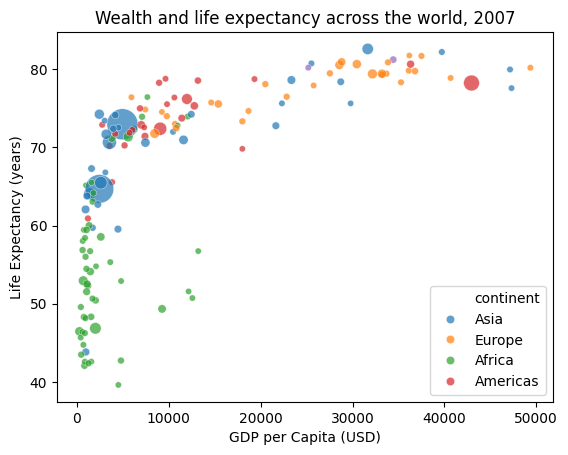

In [ ]:
# LISTING: 1.2

df_2007 = df[df['year'] == 2007].copy()

ax = sns.scatterplot(data=df_2007, x='gdpPercap', y='lifeExp',
                     hue='continent', size='pop',
                     sizes=(20, 500), alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5])

plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Life Expectancy (years)')
plt.title('Wealth and life expectancy across the world, 2007')
plt.show()

## Code Example 1.3 — Logarithmic scale reveals the structure

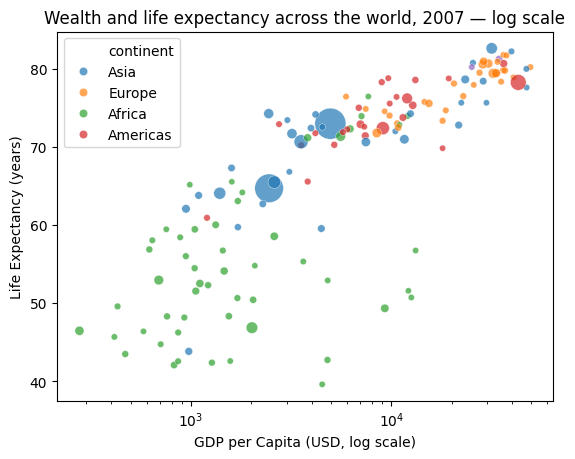

In [ ]:
# LISTING: 1.3

ax = sns.scatterplot(data=df_2007, x='gdpPercap', y='lifeExp',
                     hue='continent', size='pop',
                     sizes=(20, 500), alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5])

plt.xscale('log')
plt.xlabel('GDP per Capita (USD, log scale)')
plt.ylabel('Life Expectancy (years)')
plt.title('Wealth and life expectancy across the world, 2007 — log scale')
plt.show()

## Code Example 1.4 — How has the relationship changed over time?

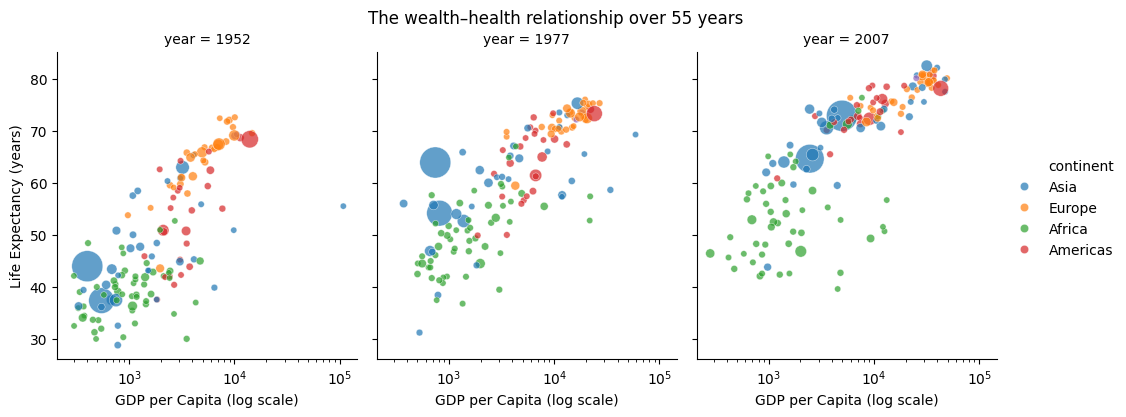

In [ ]:
# LISTING: 1.4

g = sns.FacetGrid(df[df['year'].isin([1952, 1977, 2007])],
                  col='year', height=4, aspect=0.85, sharey=True)

g.map_dataframe(sns.scatterplot, x='gdpPercap', y='lifeExp',
                hue='continent', size='pop',
                sizes=(20, 500), alpha=0.7)

g.set(xscale='log')
g.set_axis_labels('GDP per Capita (log scale)', 'Life Expectancy (years)')

handles, labels = g.axes.flat[-1].get_legend_handles_labels()
g.add_legend(legend_data=dict(zip(labels[:5], handles[:5])))

plt.suptitle('The wealth–health relationship over 55 years', y=1.02)
plt.show()

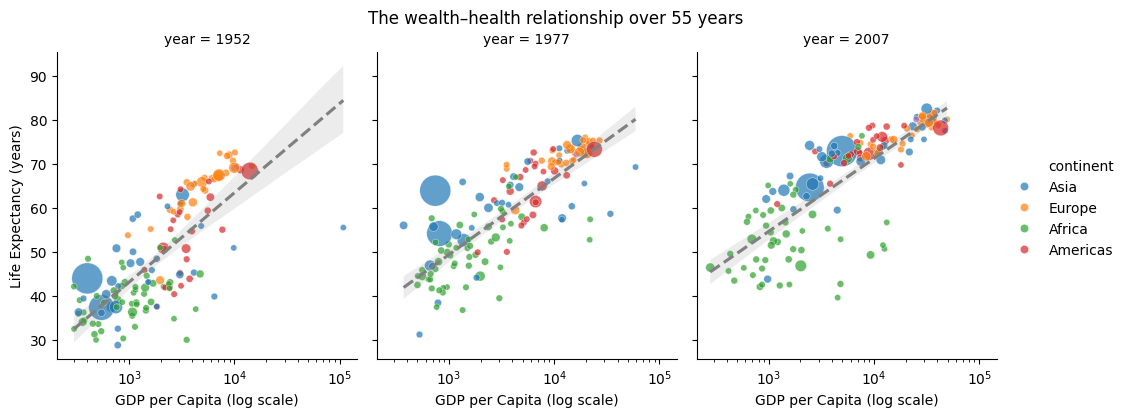

In [ ]:
g = sns.FacetGrid(df[df['year'].isin([1952, 1977, 2007])],
                  col='year', height=4, aspect=0.85, sharey=True)

g.map_dataframe(sns.scatterplot, x='gdpPercap', y='lifeExp',
                hue='continent', size='pop',
                sizes=(20, 500), alpha=0.7)

# Add regression lines to each facet
g.map_dataframe(sns.regplot, x='gdpPercap', y='lifeExp', scatter=False, logx=True, color='gray', line_kws={'linestyle': '--'})

g.set(xscale='log')
g.set_axis_labels('GDP per Capita (log scale)', 'Life Expectancy (years)')

handles, labels = g.axes.flat[-1].get_legend_handles_labels()
g.add_legend(legend_data=dict(zip(labels[:5], handles[:5])))

plt.suptitle('The wealth–health relationship over 55 years', y=1.02)
plt.show()

## Code Example 1.5 — Annotated chart for an executive audience

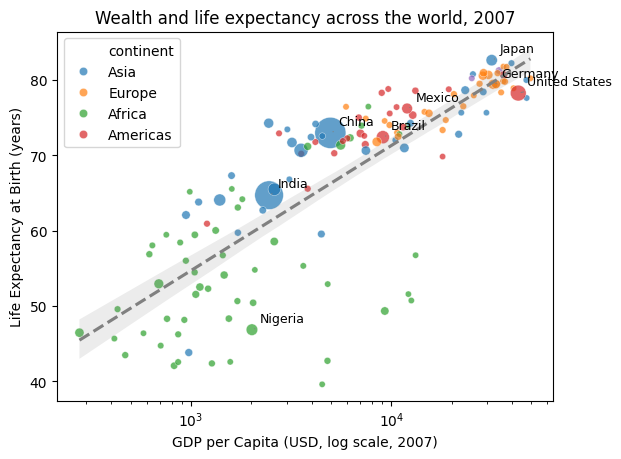

In [ ]:
# LISTING: 1.5

ax = sns.scatterplot(data=df_2007, x='gdpPercap', y='lifeExp',
                     hue='continent', size='pop',
                     sizes=(20, 500), alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5])

for country in ['United States', 'China', 'India', 'Brazil',
                'Nigeria', 'Germany', 'Japan', 'Mexico']:
    row = df_2007[df_2007['country'] == country].iloc[0]
    plt.annotate(country,
                 xy=(row.gdpPercap, row.lifeExp),
                 xytext=(row.gdpPercap * 1.1, row.lifeExp + 1),
                 fontsize=9,
                 arrowprops=dict(arrowstyle='-', color='gray', lw=0.7))

# Add the regression line
sns.regplot(data=df_2007, x='gdpPercap', y='lifeExp', ax=ax, scatter=False, logx=True, color='gray', line_kws={'linestyle': '--'})

plt.xscale('log')
plt.xlabel('GDP per Capita (USD, log scale, 2007)')
plt.ylabel('Life Expectancy at Birth (years)')
plt.title('Wealth and life expectancy across the world, 2007')
plt.show()

---
## Exercises

Use the cells below to work through the end-of-chapter exercises.  
Exercises marked *open-ended* do not have a unique correct answer — they require judgment, not just computation.

In [ ]:
# Exercise 1.2
# Extend the decade comparison to include 1962 and 1992.
# What additional patterns do you observe?


In [ ]:
# Exercise 1.3
# The trend line in Code Example 1.3 is a log-linear fit.
# What does the slope coefficient mean in plain language?
# Print the coefficient and write your interpretation as a comment.


In [ ]:
# Exercise 1.5
# Modify Code Example 1.4 to highlight the 10 most populous
# countries in 2007. Where do they fall in the distribution?


In [ ]:
# Exercise 1.6 (Challenge)
# Reproduce the full analysis for a year of your choice.
# Then compute, for each continent, the correlation between
# log GDP per capita and life expectancy.
# Does the strength of the relationship vary by continent?
